In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Семинар 2 — Линейная регрессия


# 1. Линейная модель

  
$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i 
$$

где:
- $y_i$ — наблюдаемый target;
- $x_i$ — признак;
- $\beta_0$ — intercept;
- $\beta_1$ — slope;
- $\varepsilon_i$ — то, что модель не объяснила.

Прогноз:

$$
\hat y_i = \hat\beta_0 + \hat\beta_1 x_i
$$

Residual:

$$
e_i = y_i - \hat y_i.
$$

# Рассмотрим на примере прогнозирования стоимости квартиры

In [2]:
df = pd.read_csv("data/linear_regression_demo.csv")
df.head()

,area,rooms,distance_to_center,building_age,price
0,98.5,4,6.32,55.0,13.347
1,66.7,4,21.39,19.3,11.056
2,106.6,5,9.03,36.5,16.178
3,91.2,4,21.41,27.9,15.989
4,33.9,2,7.82,24.0,5.869


sklearn intercept: 0.5564569342212948
sklearn coef: 0.1360916204771512


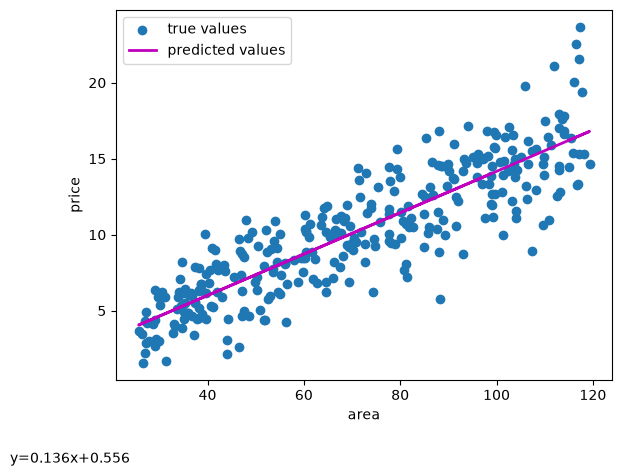

In [3]:
y=df['price']
x=df[['area']]


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

print("sklearn intercept:", model.intercept_)
print("sklearn coef:", model.coef_[0])


f, ax = plt.subplots()
ax.scatter(x, y, label='true values')
ax.plot(x, x*model.coef_[0]+model.intercept_, label='predicted values', c='m', lw=2)
ax.set_xlabel('area')
ax.set_ylabel('price')
ax.text(-1,-5,f'y={round(model.coef_[0],3)}x+{round(model.intercept_,3)}')
plt.legend()
plt.show()

## 3. Методы оценки коэффициентов

Существуют раздичные методы оценки коэффициентов модели.
Далее будем рассматривать МНК

При выполнении предпосылок теоремы Гаусса–Маркова коэффициенты МНК обладают очень важным свойством:

$$ \boxed{\hat\beta_{OLS}\text{ — BLUE}} $$

То есть Best Linear Unbiased Estimator — лучшая линейная несмещённая оценка коэффициентов.

Это означает три вещи:

Linear — оценка коэффициентов является линейной функцией наблюдений \(y\).

Unbiased — коэффициенты в среднем попадают в истинные значения:

$$ E(\hat\beta)=\beta. $$

Если много раз получать новые выборки и строить регрессию, среднее значение оценённого коэффициента будет равно истинному коэффициенту.

Best — среди всех линейных несмещённых оценок OLS имеет минимальную дисперсию:

$$ Var(\hat\beta_{OLS}) \le Var(\tilde\beta) $$

для любой другой линейной несмещённой оценки $ \tilde\beta\ $.


МНК выбирает коэффициенты, минимизирующие сумму квадратов ошибок:

$$
\min_{\beta_0,\beta_1}\sum_i(y_i-\beta_0-\beta_1x_i)^2.
$$




## 4. Множественная регрессия

$$
y_i = \beta_0 + \beta_1x_{i1}+\cdots+\beta_px_{ip}+\varepsilon_i.
$$

Интерпретация коэффициента: изменение прогноза $y$ при увеличении соответствующего признака на 1 единицу **при фиксированных остальных признаках**.

Регрессия без константы
area                  0.123769
rooms                 0.843611
distance_to_center   -0.081660
building_age          0.004063
dtype: float64
mean error 0.16214


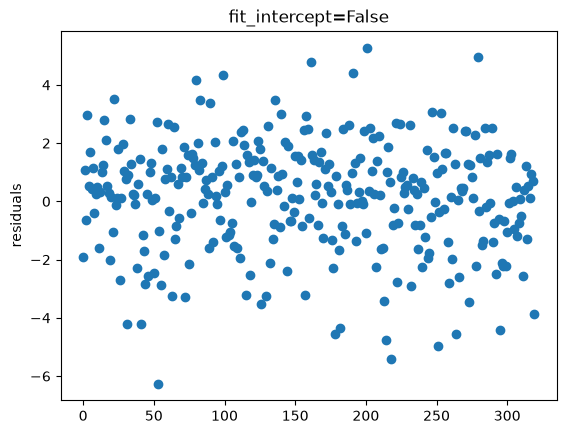


Регрессия с константой
mean error -0.0
intercept             2.675795
area                  0.109108
rooms                 0.744678
distance_to_center   -0.127157
building_age         -0.017663
dtype: float64


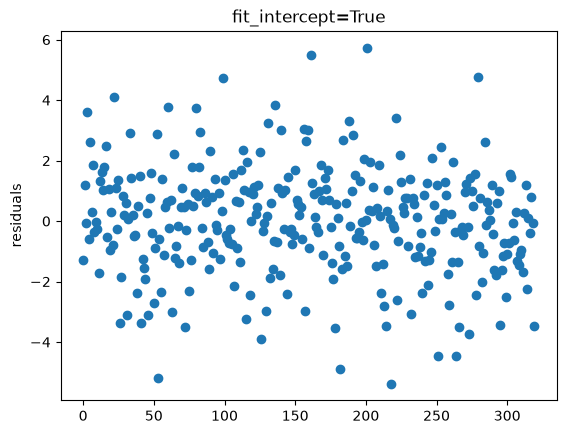

In [4]:
features = ["area", "rooms", "distance_to_center", "building_age"]
X = df[features]
y = df["price"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)
y_pred = model.predict(X)

print('Регрессия без константы')
print(pd.Series(model.coef_, index=features))
print('mean error', round((y-y_pred).mean(),5))

f,ax = plt.subplots()
ax.set_title('fit_intercept=False')
ax.scatter(range(len(y)), y-y_pred)
ax.set_ylabel('residuals')
plt.show()

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
print('\nРегрессия с константой')
print('mean error', round((y-y_pred).mean(),5))

print(pd.Series(np.insert(model.coef_, 0, model.intercept_), index=['intercept']+features))
f,ax = plt.subplots()
ax.set_title('fit_intercept=True')
ax.scatter(range(len(y)), y-y_pred)
ax.set_ylabel('residuals')
plt.show()


# 4. Train test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, y_train, X_test, y_test = train_test_split(x,y, train_size=.8, random_state=2)


## 5. Метрики: MAE, RMSE, MAPE, $R^2$

### MAE
$$
MAE=\frac1n\sum_i|y_i-\hat y_i|
$$

### RMSE
$$
RMSE=\sqrt{\frac1n\sum_i(y_i-\hat y_i)^2}
$$

### MAPE
$$
MAPE=\frac{100\%}{n}\sum_i\left|\frac{y_i-\hat y_i}{y_i}\right|
$$

### $R^2$
$$
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}
$$



### Какую метрику смотреть?

**MAE** — если нужна средняя ошибка в исходных единицах и не хочется чрезмерно штрафовать редкие большие промахи.

**RMSE** — если большие ошибки действительно экономически дороже маленьких.

**MAPE** — если важна относительная ошибка в процентах и target положителен и не близок к нулю.

**$R^2$** — показывает улучшение относительно прогноза средним, но не является ошибкой в процентах.

### Ограничение MAPE
При $y\approx0$ MAPE становится нестабильной, а при $y=0$ классическая MAPE не определена.

In [6]:
def calculate_metrics(y_true, y_pred, y_true_train, y_pred_train):
    metrics = {
        "train_rmse": root_mean_squared_error(y_true_train, y_pred_train),
        "test_rmse": root_mean_squared_error(y_true, y_pred),
        "train_mae": mean_absolute_error(y_true_train, y_pred_train),
        "test_mae": mean_absolute_error(y_true, y_pred),
        "train_mape": mean_absolute_percentage_error(y_true_train, y_pred_train),
        "test_mape": mean_absolute_percentage_error(y_true, y_pred),
        "train_r2": r2_score(y_true_train, y_pred_train),
        "test_r2": r2_score(y_true, y_pred)
    }

    return pd.DataFrame({'train': [metrics['train_rmse'], metrics['train_mae'], metrics['train_mape'], metrics['train_r2']],
                         'test': [metrics['test_rmse'], metrics['test_mae'], metrics['test_mape'], metrics['test_r2']]},
                        index=['RMSE', 'MAE', 'MAPE', 'R2']).round(3)


In [7]:
features = ["area", "rooms", "distance_to_center", "building_age"]
X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=.8, random_state=2)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(pd.Series(np.insert(model.coef_, 0, model.intercept_), index=['intercept']+features))
print(calculate_metrics(y_test, y_pred, y_train, y_pred_train))

intercept             2.592519
area                  0.107768
rooms                 0.765968
distance_to_center   -0.122363
building_age         -0.015701
dtype: float64
      train   test
RMSE  1.801  1.663
MAE   1.390  1.235
MAPE  0.161  0.135
R2    0.812  0.867


# 6. Feature scaling

Для OLS без регуляризации scaling обычно не нужен ради самих predictions.

Но он важен для:
- numerical conditioning;
- gradient descent;
- regularized linear models;
- сравнения коэффициентов по масштабу.

$$
x' = \frac{x-\mu}{\sigma}
$$

Действительно важен scaler:
1) для сравнимости коэффициентов
2) для Ridge, Lasso, ElasticNet
3) иногда решает проблемы при большом разбросе между признаками, в данных возникает ситуация,  когда маленькое изменение входных данных может привести к очень большому изменению результата вычислений

In [8]:
from sklearn.preprocessing import StandardScaler

features = ["area", "rooms", "distance_to_center", "building_age"]
X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=.8, random_state=2)

sc = StandardScaler()
sc.fit(X_train)

X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

print(pd.Series(np.insert(model.coef_, 0, model.intercept_), index=['intercept']+features))
print(calculate_metrics(y_test, y_pred, y_train, y_pred_train))




intercept             10.135410
area                   2.865141
rooms                  0.848180
distance_to_center    -0.887502
building_age          -0.267038
dtype: float64
      train   test
RMSE  1.801  1.663
MAE   1.390  1.235
MAPE  0.161  0.135
R2    0.812  0.867


# Анализ самых больших ошибок

Почему модель особенно сильно ошиблась именно на этих объектах

Что можно найти:

- выбросы;

- ошибки данных;

- пропущенные признаки;

- отдельные сегменты;

- нелинейности


In [17]:
errors = X_test.copy()

errors["y_true"] = y_test
errors["y_pred"] = model.predict(X_test)
errors["residual"] = errors["y_true"] - errors["y_pred"]
errors["abs_error"] = errors["residual"].abs()

errors.sort_values("abs_error", ascending=False).head(10)

/Users/irinakharkova/my_projects/ml_course/2 семинар линейнай регрессия/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,area,rooms,distance_to_center,building_age,y_true,y_pred,residual,abs_error
99,116.4,5,6.44,26.6,22.558,335.060040,-312.502040,312.502040
11,113.0,3,8.88,9.2,14.226,326.103162,-311.877162,311.877162
190,114.0,3,10.50,10.1,16.815,327.290216,-310.475216,310.475216
169,115.5,3,7.72,49.9,16.351,323.427058,-307.076058,307.076058
292,112.9,4,6.51,48.4,14.514,318.300305,-303.786305,303.786305
151,110.1,4,3.59,25.4,17.475,319.011296,-301.536296,301.536296
109,110.7,5,1.66,55.4,16.399,315.280290,-298.881290,298.881290
197,108.1,3,4.87,23.7,15.627,311.750796,-296.123796,296.123796
180,109.6,3,17.10,9.2,14.645,309.066415,-294.421415,294.421415
304,106.5,3,13.18,6.2,14.670,304.464599,-289.794599,289.794599


## 7. Как читать `statsmodels.summary()`

Это та же линейная регрессия, но `statsmodels` делает акцент на statistical inference.

| Поле                 | Что означает                   | Как интерпретировать                               |
| -------------------- | ------------------------------ | -------------------------------------------------- |
| `Dep. Variable`      | зависимая переменная           | что предсказываем                                  |
| `Model`              | тип модели                     | обычно `OLS`                                       |
| `Method`             | метод оценки                   | `Least Squares`                                    |
| `No. Observations`   | число наблюдений               | размер выборки                                     |
| `Df Residuals`       | степени свободы остатков       | примерно `n - число параметров`                    |
| `Df Model`           | число объясняющих переменных   | без константы                                      |
| `R-squared`          | коэффициент детерминации       | доля объяснённой вариации                          |
| `Adj. R-squared`     | скорректированный R²           | учитывает число признаков                          |
| `F-statistic`        | F-тест модели целиком          | проверяет, есть ли хоть один ненулевой коэффициент |
| `Prob (F-statistic)` | p-value F-теста                | маленькое значение → модель в целом значима        |
| `Log-Likelihood`     | логарифм likelihood            | нужен для AIC/BIC и сравнения моделей              |
| `AIC`                | Akaike Information Criterion   | меньше лучше среди моделей на одних данных         |
| `BIC`                | Bayesian Information Criterion | тоже меньше лучше, но сильнее штрафует сложность   |


In [18]:
res = smf.ols(
    "price ~ area + rooms + distance_to_center + building_age",
    data=df
).fit()

res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     371.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          8.26e-118
Time:                        11:25:59   Log-Likelihood:                -637.33
No. Observations:                 320   AIC:                             1285.
Df Residuals:                     315   BIC:                             1304.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.6758      0.406      6.593      0.000       1.877       3.474
area                   0.1091      0.006     18.409      0.000       0.097       0.121
rooms                  0.7447      0.144      5.183      0.000       0.462       1.027
distance_to_center    -0.1272      0.014     -9.146      0.000      -0.155      -0.100
building_age          -0.0177      0.006     -3.007      0.003      -0.029      -0.006
==============================================================================
Omnibus:                        4.957   Durbin-Watson:                   2.049
Prob(Omnibus):                  0.084   Jarque-Bera (JB):                6.470
Skew:                          -0.072   Prob(JB):                       0.0394
Kurtosis:                       3.681   Cond. No.                         334.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### На что смотреть в report

- `coef` — оценка коэффициента;
- `std err` — неопределенность оценки;
- `t` — отношение коэффициента к standard error;
- `P>|t|` — p-value для $H_0:\beta_j=0$;
- `[0.025, 0.975]` — 95% confidence interval;
- `R-squared` — доля объясненной вариации;
- `Adj. R-squared` — $R^2$ со штрафом за число predictors.

> **Важно:** $p>0.05$ не означает, что $\beta=0$. Это означает, что данных недостаточно, чтобы отвергнуть $H_0:\beta=0$ на выбранном уровне значимости.

> **Statistical significance ≠ economic significance ≠ predictive usefulness.**

## 8. Nonlinearity

Линейная регрессия может плохо описывать данные, если conditional mean нелинеен.

Но модель

$$
y = \beta_0 + \beta_1x + \beta_2x^2
$$

все еще линейна по параметрам.

In [19]:
rng = np.random.default_rng(2)

x_nl = rng.uniform(-3, 3, 300)
y_nl = 3 + 2*x_nl + 0.8*(x_nl**2) + rng.normal(0, 1.0, 300)

X1 = x_nl.reshape(-1,1)
m1 = LinearRegression().fit(X1, y_nl)
pred1 = m1.predict(X1)

X2 = np.c_[x_nl, x_nl**2]
m2 = LinearRegression().fit(X2, y_nl)
pred2 = m2.predict(X2)

print("Linear RMSE:", mean_squared_error(y_nl, pred1)**0.5)
print("Quadratic RMSE:", mean_squared_error(y_nl, pred2)**0.5)


print("Linear R2_score:", r2_score(y_nl, pred1))
print("Quadratic R2_score:", r2_score(y_nl, pred2))

Linear RMSE: 2.381959177812026
Quadratic RMSE: 0.9684402782454519
Linear R2_score: 0.6754973051431308
Quadratic R2_score: 0.9463591851003477


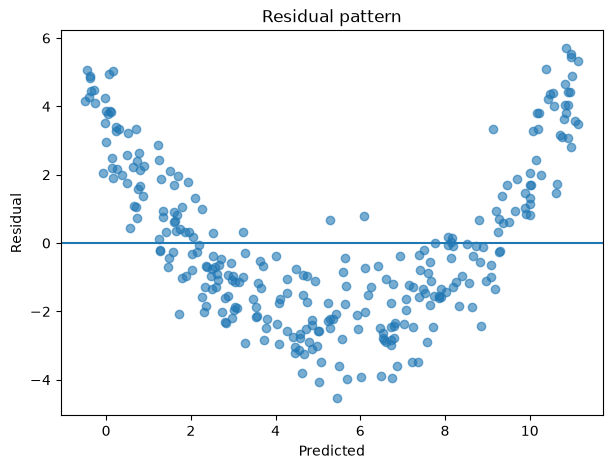

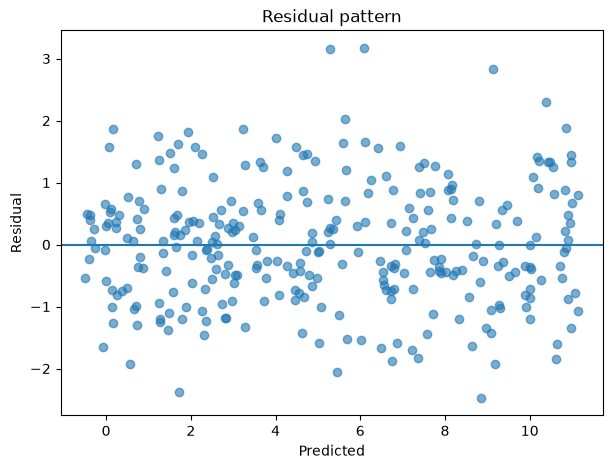

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(pred1, y_nl - pred1, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual pattern")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(pred1, y_nl - pred2, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual pattern")
plt.show()

## 9. Outliers

Squared loss сильно штрафует крупные ошибки, поэтому OLS чувствителен к outliers.

In [21]:
x_o = np.arange(1, 11)
y_o = 2*x_o + np.random.default_rng(3).normal(0, 1, len(x_o))

m_clean = LinearRegression().fit(x_o.reshape(-1,1), y_o)

x_out = np.append(x_o, 11)
y_out = np.append(y_o, 50)
m_out = LinearRegression().fit(x_out.reshape(-1,1), y_out)

print("Slope without outlier:", m_clean.coef_[0])
print("Slope with outlier:", m_out.coef_[0])

Slope without outlier: 2.0969826283680297
Slope with outlier: 3.3505860403258096


## 10. Multicollinearity

Если признаки почти линейно зависимы, predictions могут оставаться стабильными, а отдельные коэффициенты — сильно меняться.

In [22]:
rng = np.random.default_rng(4)
x1 = rng.normal(size=300)
x2 = x1 + rng.normal(0, 0.05, 300)
y_mc = 5 + 3*x1 + 3*x2 + rng.normal(0, 1, 300)

def fit_on_sample(seed):
    rr = np.random.default_rng(seed)
    idx = rr.choice(len(x1), size=220, replace=True)
    mm = LinearRegression().fit(np.c_[x1[idx], x2[idx]], y_mc[idx])
    return mm.coef_

pd.DataFrame([fit_on_sample(s) for s in range(10)], columns=["beta_x1","beta_x2"])

,beta_x1,beta_x2
0,0.984455,5.157906
1,6.232753,-0.063687
2,1.555581,4.500115
3,2.406353,3.682107
4,1.391263,4.682733
5,1.144702,4.896666
6,1.223392,4.854220
7,-0.224538,6.329300
8,-1.959529,8.079925
9,1.692306,4.393107


## 11. Levels, logs and elasticity

### Level-level
$$
y=\beta_0+\beta_1x+\varepsilon
$$
$+1$ единица $x$ связана с $\beta_1$ единиц изменения $y$.

### Log-level
$$
\ln y=\beta_0+\beta_1x+\varepsilon
$$
При небольших $\beta_1$: $+1$ единица $x$ связана примерно с $100\beta_1\%$ изменением $y$.

Точнее:
$$
100(e^{\beta_1}-1)\%.
$$

### Level-log
$$
y=\beta_0+\beta_1\ln x+\varepsilon
$$
Рост $x$ на 1% связан примерно с $\beta_1/100$ единиц изменения $y$.

### Log-log
$$
\ln y=\beta_0+\beta_1\ln x+\varepsilon
$$
$\beta_1$ — elasticity.

## 12. Heteroskedasticity

Heteroskedasticity означает, что

$$
Var(\varepsilon_i|X_i)
$$

не является постоянной.

Это не обязательно разрушает сами OLS coefficients, но обычные standard errors могут стать некорректными.

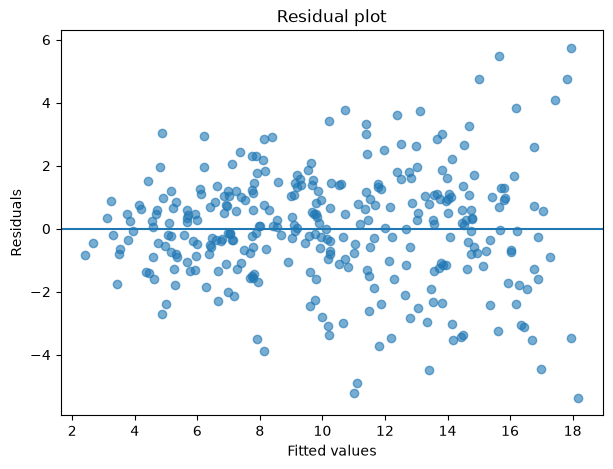

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(res.fittedvalues, res.resid, alpha=0.6)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

In [24]:
res_hc3 = smf.ols(
    "price ~ area + rooms + distance_to_center + building_age",
    data=df
).fit(cov_type="HC3")

comparison = pd.DataFrame({
    "coef": res.params,
    "SE_classic": res.bse,
    "SE_HC3": res_hc3.bse,
    "p_classic": res.pvalues,
    "p_HC3": res_hc3.pvalues
})
comparison

,coef,SE_classic,SE_HC3,p_classic,p_HC3
Intercept,2.675795,0.405837,0.390210,1.813340e-10,7.016746e-12
area,0.109108,0.005927,0.006049,6.869840e-52,9.696059e-73
rooms,0.744678,0.143682,0.158557,3.912365e-07,2.645409e-06
distance_to_center,-0.127157,0.013903,0.014693,7.536572e-18,4.965854e-18
building_age,-0.017663,0.005874,0.006136,2.849413e-03,3.992057e-03


## 13. Assumptions: 

| Assumption | Для оценки взаимодействия | Для стат выводах о коэффициентах | Для prediction |
|---|---|---|---|
|  $E[\varepsilon/X]=0$ | важно | важно | важно |
| no multicollinearity | необходимо | необходимо | практически необходимо |
| homoskedasticity | не обязательно для коэффициентов | важно для classic SE | не обязательно |
| normality of errors | не нужна для OLS | полезна для exact small-sample tests | почти не нужна |
| independence | зависит от дизайна | важна для SE/tests | влияет на validation |

> Нельзя механически перечислять assumptions — нужно понимать, **для какого вывода** каждое из них нужно.

# Likelihood → AIC/BIC

## 14. Почему likelihood связан с regression

Предположим:

$$
Y_i|X_i=x_i \sim N(x_i^T\beta,\sigma^2).
$$

Тогда likelihood одного наблюдения:

$$
p(y_i|x_i,\beta,\sigma)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i-x_i^T\beta)^2}{2\sigma^2}
\right).
$$

Для всей выборки при conditional independence:

$$
L(\beta,\sigma)=\prod_i p(y_i|x_i,\beta,\sigma).
$$

Логарифмируя:

$$
\ell(\beta,\sigma)
=
C
-
\frac{1}{2\sigma^2}
\sum_i(y_i-x_i^T\beta)^2.
$$

Поэтому при Gaussian errors:

$$
\boxed{OLS = Maximum\ Likelihood}
$$

по $\beta$.

## 15. Почему нельзя просто максимизировать likelihood?

Более сложная модель обычно может лучше подогнаться под training data.

Поэтому нужна идея:

$$
\text{fit} - \text{penalty for complexity}.
$$

##  AIC и BIC

$$
AIC = 2k - 2\ell(\hat\theta)
$$

$$
BIC = k\ln n - 2\ell(\hat\theta)
$$

где:
- $k$ — число оцениваемых parameters;
- $n$ — число observations;
- $\ell(\hat\theta)$ — maximized log-likelihood.

Меньше — лучше **среди сопоставимых моделей**.

### AIC vs BIC

- **AIC** обычно мягче штрафует сложность и связан с predictive approximation.
- **BIC** при обычных размерах выборки штрафует complexity сильнее и имеет Bayesian interpretation.

Они не равны test error.

**Test error** измеряется на новых observations.

**AIC/BIC** используют training likelihood и аналитический penalty.

In [25]:
rng = np.random.default_rng(2)
x_nl = rng.uniform(-3, 3, 300)
y_nl = 3 + 2*x_nl + 0.8*(x_nl**2) + rng.normal(0, 1.0, 300)

rows = []
for deg in range(1, 11):
    tmp = pd.DataFrame({"x": x_nl, "y": y_nl})
    for d in range(2, deg+1):
        tmp[f"x{d}"] = tmp["x"]**d
    formula = "y ~ " + " + ".join(["x"] + [f"x{d}" for d in range(2, deg+1)])
    rr = smf.ols(formula, data=tmp).fit()
    pred = rr.predict(tmp)
    rows.append({
        "degree": deg,
        "train_RMSE": mean_squared_error(tmp["y"], pred)**0.5,
        "AIC": rr.aic,
        "BIC": rr.bic
    })

pd.DataFrame(rows)

,degree,train_RMSE,AIC,BIC
0,1,2.381959,1376.117120,1383.524685
1,2,0.968440,838.122043,849.233390
2,3,0.966693,839.038820,853.853950
3,4,0.961801,837.994215,856.513128
4,5,0.961801,839.994213,862.216908
5,6,0.960904,841.434806,867.361283
6,7,0.958685,842.047657,871.677917
7,8,0.957776,843.478068,876.812110
8,9,0.956571,844.723220,881.761045
9,10,0.955960,846.339482,887.081090
